# <p style="background-color:DarkOrange; font-family:calibri; color:Indigo; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | E-commerce Product Delivery Prediction </p>

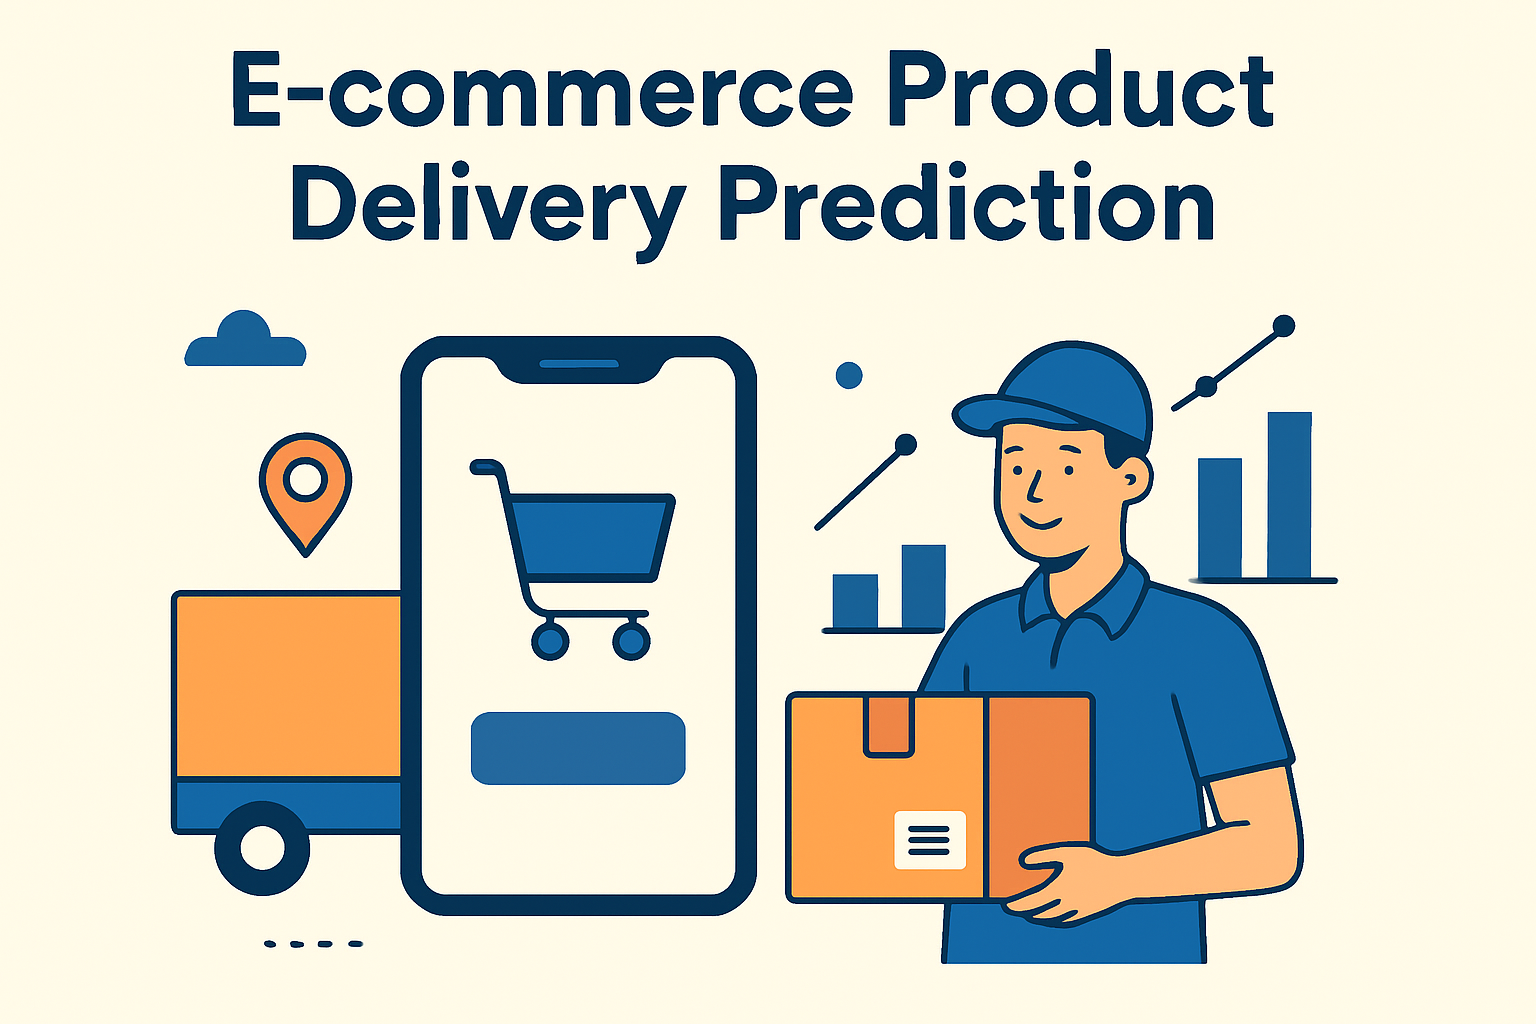

<a id="import"></a>
# <p style="background-color:Black; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;"> Step 1 | Import Libraries</p>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

* Pandas is used to read a dataset and All Dataframe Operations.
* Numpy For Numeric Operations
* Matplotlib and Seaborn Are Data Visualization Libraries
* Scikit Learn for All Machine Learning Algorithms

<a id="import"></a>
# <p style="background-color:Black; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

In [34]:
#Loading the dataset
df = pd.read_csv(r"C:\Users\saiso\Downloads\E_Commerce.csv")

In [48]:
# Display first few rows of the data frame
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [52]:
## checking the shape dataset
df.shape

(10999, 12)

<a id="import"></a>
# <p style="background-color:Black; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;"> Step 3. Data Exploration (Initial EDA and data cleaning)</p>

* Understand your variables
* Clean your dataset (missing data, redundant data, outliers)

# <p style="background-color:AntiqueWhite; font-family:calibri; color:DimGrey; font-size:100%; text-align:center;border-radius:15px 50px;"> Gather basic information about the data</p>

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [66]:
## Checking data types of the columns
df.dtypes

Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

# <p style="background-color:AntiqueWhite; font-family:calibri; color:DimGrey; font-size:100%; text-align:center;border-radius:15px 50px;"> Check Missing Values</p>

In [79]:
## Check null/missing values
df.isnull().sum()

Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [81]:
## Check duplicate values
df.duplicated().sum()

0

In [83]:
df.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [85]:
df.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


# <p style="background-color:AntiqueWhite; font-family:calibri; color:DimGrey; font-size:100%; text-align:center;border-radius:15px 50px;"> Data Exploration (EDA)</p>
*  During the exploratory data analysis, I will examine how the target variable interacts with other variables and analyze the distribution of these variables within the dataset to gain a deeper understanding of the data.

* Customer Gender Prediction

Text(0.5, 1.0, 'Gender Distribution')

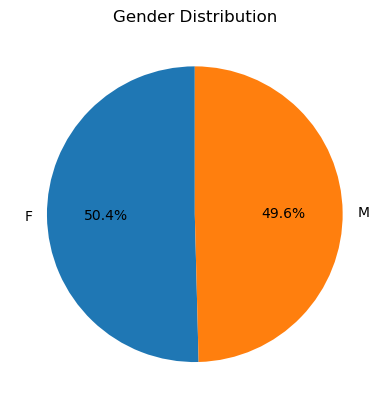

In [90]:
plt.pie(df['Gender'].value_counts(),labels = ['F','M'], autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')

*  The dataset has the equal number of both males and female customers, with percentage of 49.6% and 50.4% respectively

## Properties of Product

Text(0.5, 1.0, 'Cost of the Product')

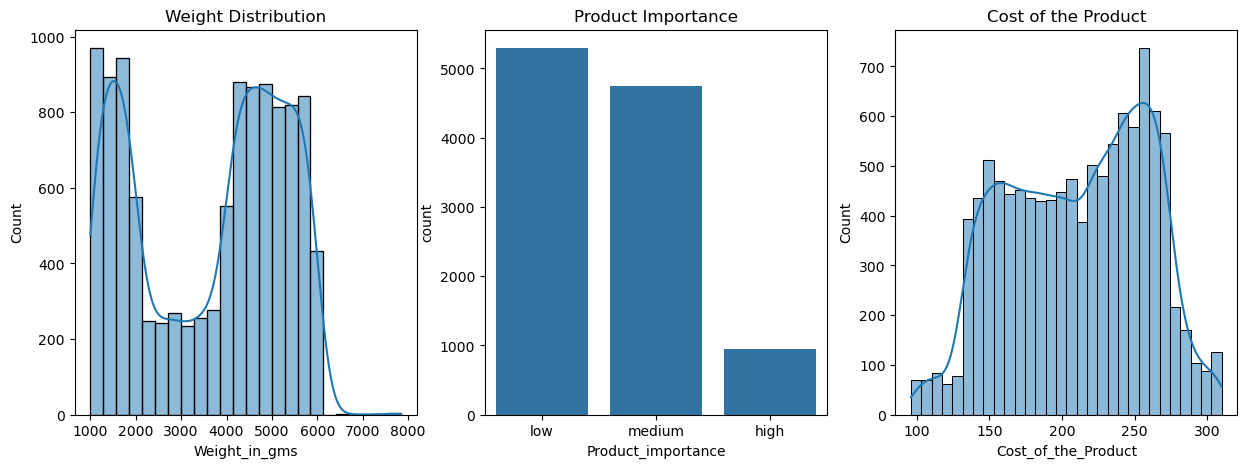

In [95]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
sns.histplot(df['Weight_in_gms'], ax=ax[0], kde=True).set_title('Weight Distribution')
sns.countplot(x = 'Product_importance', data = df, ax=ax[1]).set_title('Product Importance')
sns.histplot(df['Cost_of_the_Product'], ax=ax[2], kde=True).set_title('Cost of the Product')

* The three graphs illustrate the distribution of product characteristics such as weight, cost, and importance within the dataset. The first graph shows that products primarily weigh between 1000-2000 grams and 4000-6000 grams, indicating that these weight categories are more prevalent in the company's sales. In the second graph, which represents product importance, we observe that most products are categorized as having low or medium importance. The third graph focuses on the cost distribution, highlighting a higher frequency of products priced between 150-200 and 225-275 dollars. 
 
* Based on these observations, it's apparent that the company predominantly sells products weighing less than 6000 grams, with low to medium importance, and priced between 150-275 dollars

## Logistics

Text(0.5, 1.0, 'Reached on Time')

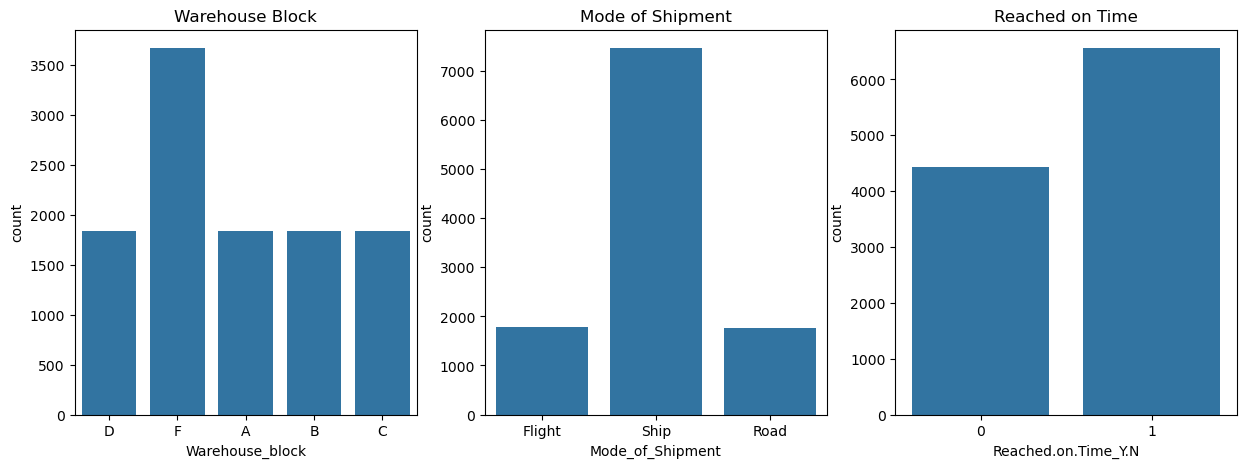

In [99]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
sns.countplot(x = 'Warehouse_block', data = df, ax=ax[0]).set_title('Warehouse Block')
sns.countplot(x = 'Mode_of_Shipment', data = df, ax=ax[1]).set_title('Mode of Shipment')
sns.countplot(x = 'Reached.on.Time_Y.N', data = df, ax=ax[2]).set_title('Reached on Time')

* The graphs present insights into the logistics and delivery aspects of the products. The first graph indicates that warehouse F handles the most products, around 3500, while the other warehouses manage a comparable and lower number of products. The second graph displays the shipping methods, revealing that the majority of products are transported by ship, with about 2000 products shipped via flight and road. The third graph illustrates delivery timeliness, showing a higher quantity of products delivered on time compared to those that are late.

* Considering these observations, it can be inferred that warehouse F might be strategically located near a seaport, as it not only has the highest volume of products but also predominantly uses shipping as the mode of transport.

## Customer Experience

Text(0.5, 1.0, 'Discount Offered')

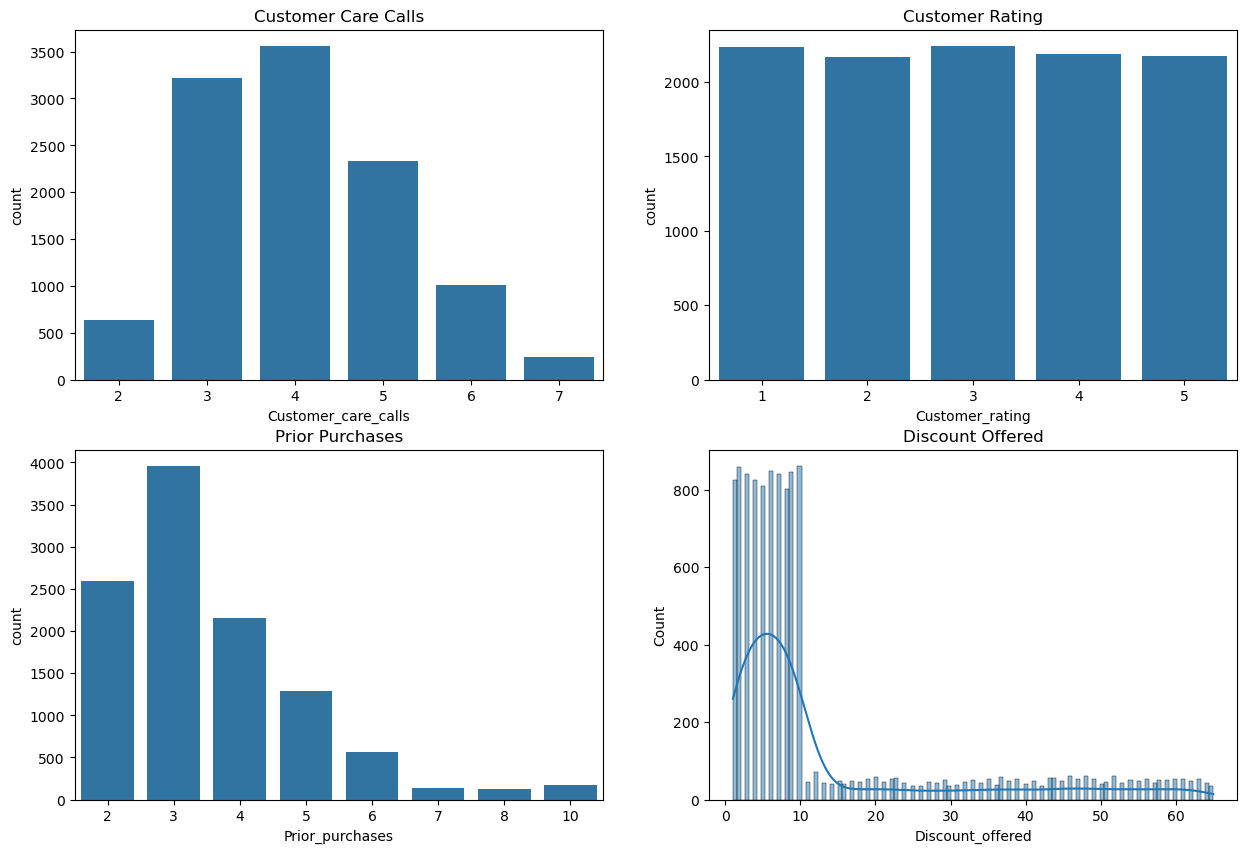

In [103]:
fig, ax = plt.subplots(2,2,figsize=(15,10))
sns.countplot(x = 'Customer_care_calls', data = df, ax=ax[0,0]).set_title('Customer Care Calls')
sns.countplot(x = 'Customer_rating', data = df, ax=ax[0,1]).set_title('Customer Rating')
sns.countplot(x = 'Prior_purchases', data = df, ax=ax[1,0]).set_title('Prior Purchases')
sns.histplot(x = 'Discount_offered', data = df, ax=ax[1,1], kde = True).set_title('Discount Offered')

* The graphs provide an overview of customer experience metrics, including customer service interactions, ratings, previous purchases, and discounts. The first graph indicates that most customers make 3-4 customer care calls, suggesting possible issues with product delivery. The second graph shows an even distribution of customer ratings, with a slight increase in 1-star ratings, hinting at some level of dissatisfaction with the service.

* The third graph reveals that a majority of customers have made 2-3 prior purchases, indicating that repeat customers are generally satisfied with the service and continue to engage with the company. The fourth graph displays the distribution of discounts, with most products receiving a 0-10% discount, suggesting that the company offers limited discounts on its products.

## Customer Gender and Product Delivery

Text(0.5, 1.0, 'Gender vs Reached on Time')

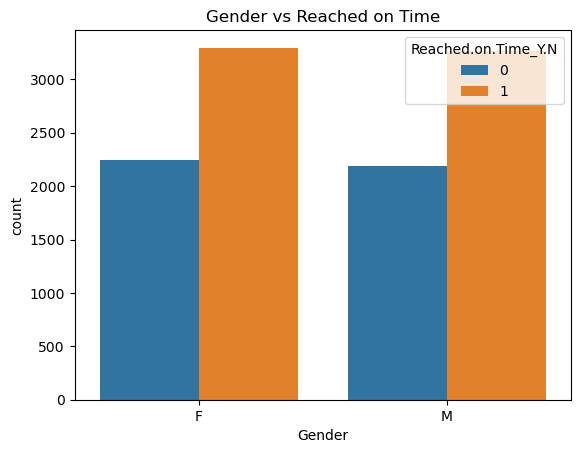

In [107]:
sns.countplot(x = 'Gender', data = df, hue = 'Reached.on.Time_Y.N').set_title('Gender vs Reached on Time')

* The data shows that the timely delivery of products is consistent across both genders, indicating that customer gender does not influence the punctuality of product delivery.

## Product Properties and Product Delivery

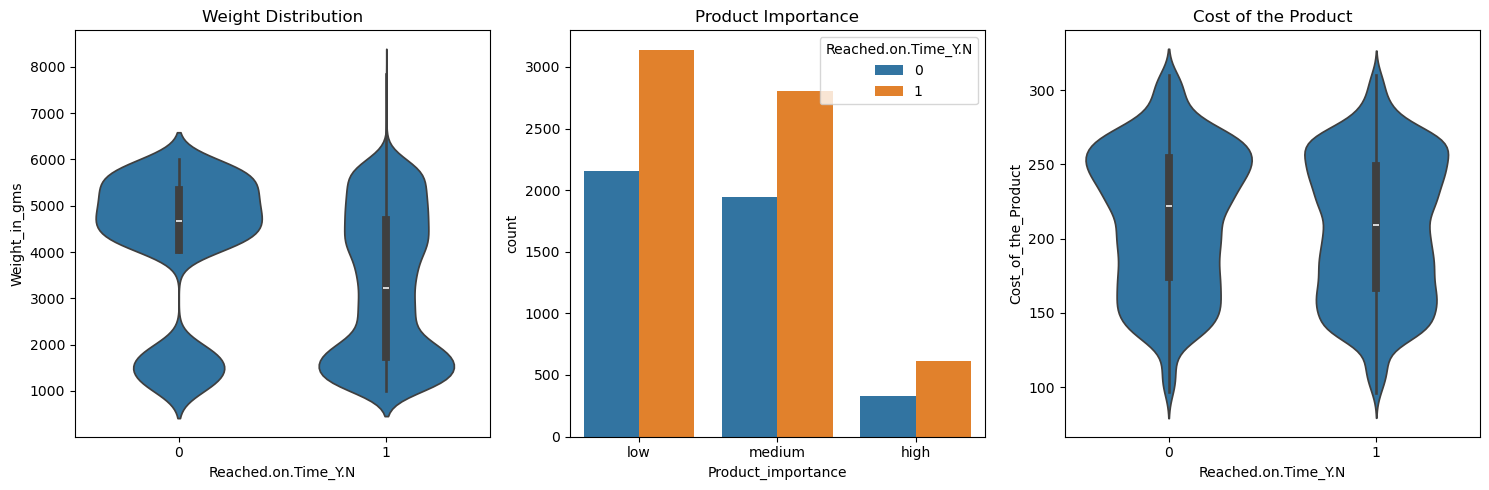

In [111]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.violinplot(
    y=df['Weight_in_gms'], x=df['Reached.on.Time_Y.N'], ax=ax[0]
).set_title('Weight Distribution')

sns.countplot(
    x='Product_importance', data=df, hue='Reached.on.Time_Y.N', ax=ax[1]
).set_title('Product Importance')

sns.violinplot(
    y=df['Cost_of_the_Product'], x=df['Reached.on.Time_Y.N'], ax=ax[2]
).set_title('Cost of the Product')

plt.tight_layout()
plt.show()

* The graphs demonstrate the connection between logistics operations and the timely delivery of products. Given that the majority of products are dispatched from warehouse F, which is presumed to be near a seaport due to its high shipping volume, it's notable that the mode of shipment is predominantly by ship.
 
* However, the data shows a consistent difference in the number of products delivered on time versus late across all warehouses and shipping methods. This consistency suggests that the logistics, including the warehouse location and shipping method, do not significantly affect the timeliness of product delivery.

## Customer Experience and Product Delivery

Text(0.5, 1.0, 'Discount Offered')

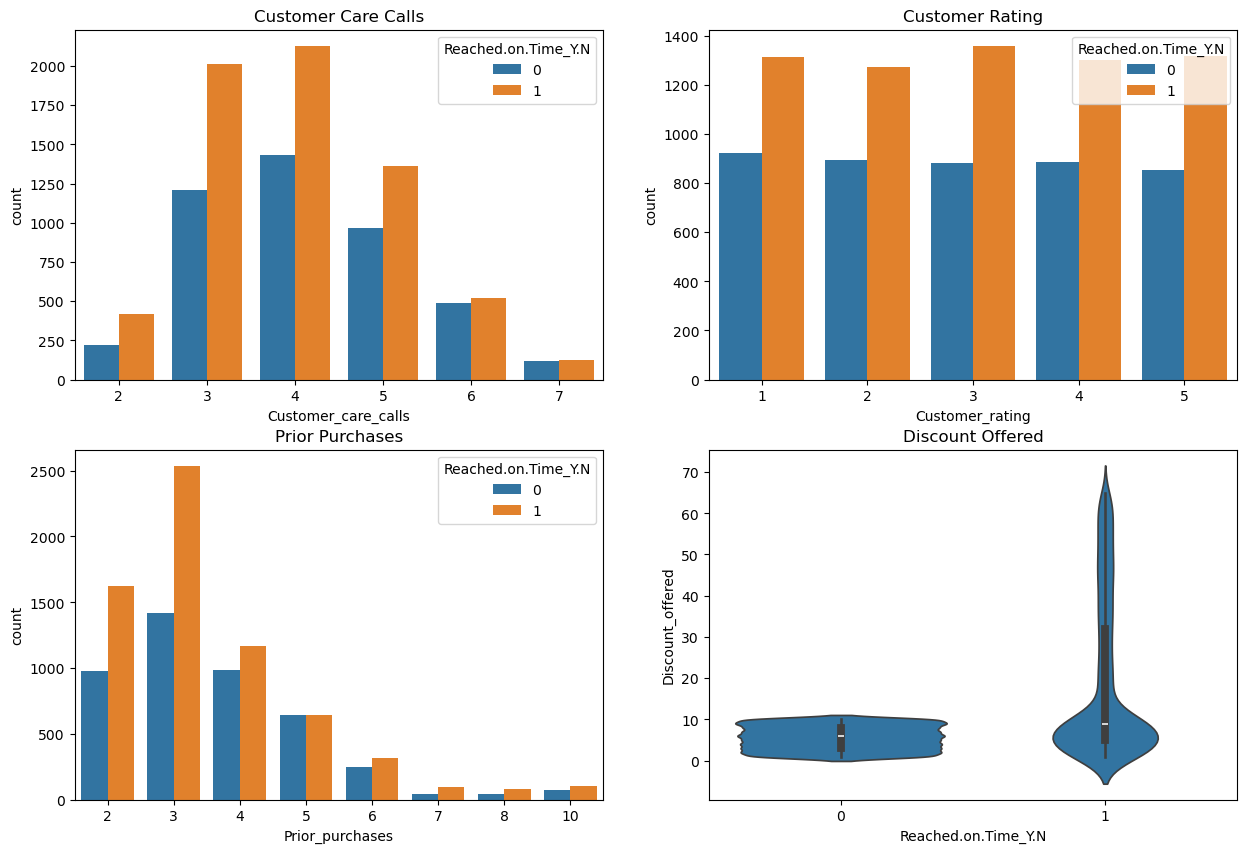

In [115]:
fig, ax = plt.subplots(2,2,figsize=(15,10))
sns.countplot(x = 'Customer_care_calls', data = df, ax=ax[0,0],hue = 'Reached.on.Time_Y.N').set_title('Customer Care Calls')
sns.countplot(x = 'Customer_rating', data = df, ax=ax[0,1],hue = 'Reached.on.Time_Y.N').set_title('Customer Rating')
sns.countplot(x = 'Prior_purchases', data = df, ax=ax[1,0],hue = 'Reached.on.Time_Y.N').set_title('Prior Purchases')
sns.violinplot(x = 'Reached.on.Time_Y.N', y = 'Discount_offered' ,data = df, ax=ax[1,1]).set_title('Discount Offered')

* The graphs link customer experience with product delivery for an E-Commerce company. The first graph shows that as customer care calls increase, on-time deliveries decrease, suggesting customers call more when deliveries are late. The second graph indicates that customers with higher ratings often receive their products on time. The third graph reveals that customers who make repeat purchases tend to receive their products on time, likely encouraging their continued business. Lastly, the fourth graph shows that products with less than 10% discount are often delivered late, while those with more than 10% discount are delivered on time more frequently.

# <p style="background-color:AntiqueWhite; font-family:calibri; color:DimGrey; font-size:100%; text-align:center;border-radius:15px 50px;">  Data Preprocessing II</p>


In [124]:
from sklearn.preprocessing import LabelEncoder

In [126]:
#Label encoding object
le = LabelEncoder()

In [128]:
#columns for label encoding
cols = ['Warehouse_block','Mode_of_Shipment','Product_importance', 'Gender']

In [130]:
#label encoding
for i in cols:
    le.fit(df[i])
    df[i] = le.transform(df[i])
    print(i, df[i].unique())

Warehouse_block [3 4 0 1 2]
Mode_of_Shipment [0 2 1]
Product_importance [1 2 0]
Gender [0 1]


## Correlation Matrix Heatmap

<Axes: >

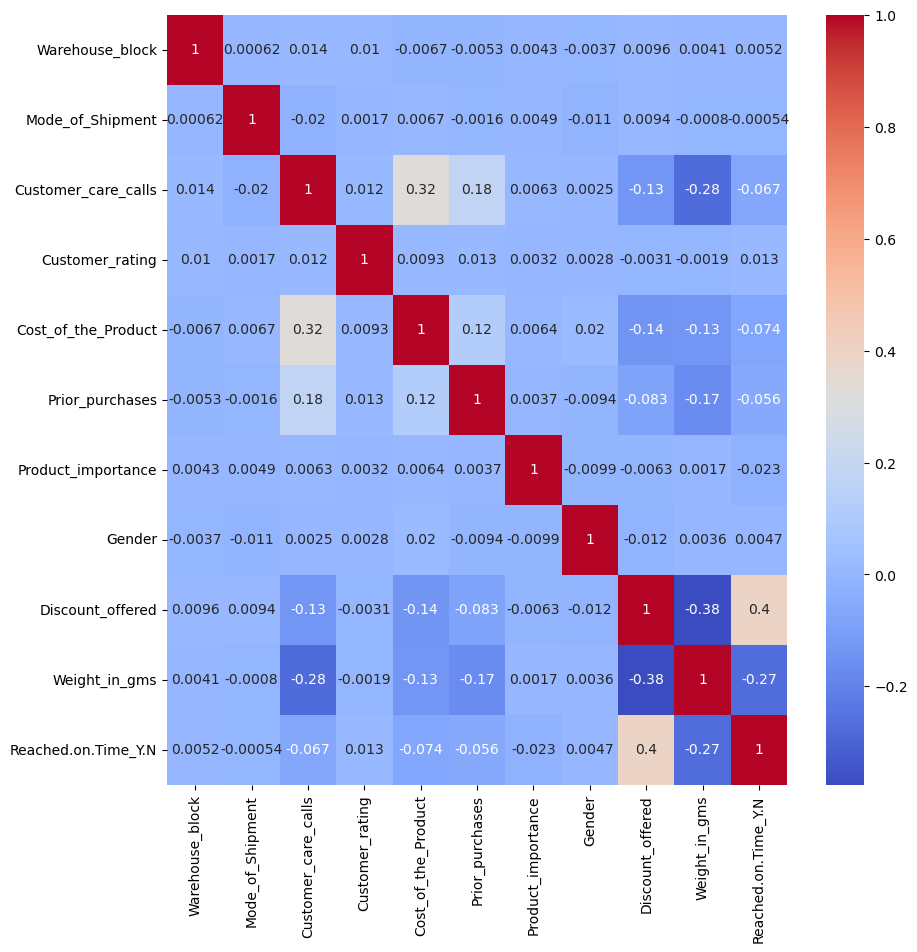

In [133]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

* The correlation matrix heatmap shows a positive correlation between the product's cost and the number of customer care calls.

<Axes: xlabel='Customer_care_calls', ylabel='Cost_of_the_Product'>

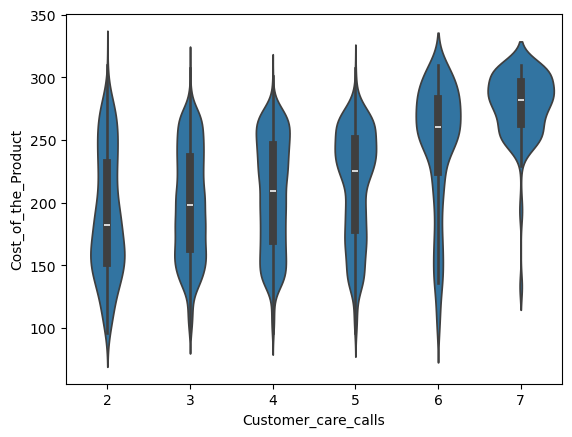

In [136]:
sns.violinplot(x = 'Customer_care_calls', y = 'Cost_of_the_Product', data = df)

* Customers tend to be more concerned about delivery when the product is expensive, leading to more customer service calls to check on the product's status. Therefore, ensuring timely delivery is crucial for high-cost items.

## Train Test Split

In [140]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Reached.on.Time_Y.N', axis=1), df['Reached.on.Time_Y.N'], test_size=0.2, random_state=0)

# <p style="background-color:Black; font-family:calibri; color:White; font-size:150%; text-align:center;border-radius:15px 50px;"> Step 4. Model Building</p>

* Using the following models to predict the product delivery:
 
1 - Random Forest Classifier
 
2 - Decision Tree Classifier
 
3 - Logistic Regression
 
4 - K Nearest Neighbors



In [146]:
from sklearn.ensemble import RandomForestClassifier

In [148]:
#Random Forest Classifier Object
rfc = RandomForestClassifier()

In [150]:
#Using GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [152]:
#Parameter grid
param_grid = {
    'max_depth': [4,8,12,16],
    'min_samples_leaf': [2,4,6,8],
    'min_samples_split': [2,4,6,8],
    'criterion': ['gini', 'entropy'],
    'random_state': [0,42]
}


In [154]:
#GridSearchCV object
grid = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

In [156]:
#Fitting the model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 8, 12, 16],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [2, 4, 6, 8],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=2)

In [157]:
#Best parameters
print('Best parameters: ', grid.best_params_)

Best parameters:  {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 8, 'min_samples_split': 2, 'random_state': 42}


In [160]:
#Random Forest Classifier Object
rfc = RandomForestClassifier(criterion='gini', max_depth=8, min_samples_leaf=8, min_samples_split=2, random_state=42)

In [162]:
#Fitting the model
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=8, random_state=42)

In [165]:
#Training accuracy
print('Training accuracy: ', rfc.score(X_train, y_train))

Training accuracy:  0.7253096942834413


In [167]:
#predicting the test set results
rfc_pred = rfc.predict(X_test)

In [169]:
## Decision Tree Classifier

In [171]:
from sklearn.tree import DecisionTreeClassifier

In [173]:
#Decision Tree Classifier Object
dtc = DecisionTreeClassifier()

In [175]:
#Using GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
#Parameter grid
param_grid = {
    'max_depth': [2,4,6,8],
    'min_samples_leaf': [2,4,6,8],
    'min_samples_split': [2,4,6,8],
    'criterion': ['gini', 'entropy'],
    'random_state': [0,42]}

In [177]:
#GridSearchCV object
grid = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

In [179]:
#Fitting the model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8],
                         'min_samples_leaf': [2, 4, 6, 8],
                         'min_samples_split': [2, 4, 6, 8],
                         'random_state': [0, 42]},
             scoring='accuracy', verbose=2)

In [181]:
#Best parameters
print('Best parameters: ', grid.best_params_)

Best parameters:  {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 2, 'random_state': 0}


In [183]:
#Decision Tree Classifier Object
dtc = DecisionTreeClassifier(criterion='gini', max_depth=6, min_samples_leaf=6, min_samples_split=2, random_state=0, class_weight='balanced')

In [185]:
#Fitting the model
dtc.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=6,
                       random_state=0)

In [187]:
#Training accuracy
print('Training accuracy: ', dtc.score(X_train, y_train))

Training accuracy:  0.6913285600636436


In [189]:
#predicting the test set results
dtc_pred = dtc.predict(X_test)

## Logistic Regression

In [192]:
from sklearn.linear_model import LogisticRegression

In [194]:
#Logistic Regression Object
lr = LogisticRegression()

In [196]:
#fitting the model
lr.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [198]:
#Training accuracy
lr.score(X_train, y_train)

0.6379133992499147

In [200]:
#predicting the test set results
lr_pred = lr.predict(X_test)

## K Nearest Neighbors

In [203]:
from sklearn.neighbors import KNeighborsClassifier

In [205]:
#KNN Classifier Object
knn = KNeighborsClassifier()

In [207]:
#fitting the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [209]:
#training accuracy
knn.score(X_train, y_train)

0.7782702579838618

In [211]:
#predicting the test set results
knn_pred = knn.predict(X_test)

## Model Evaluation

In [214]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, r2_score, mean_squared_error

Text(0.5, 1.0, 'KNN Classifier')

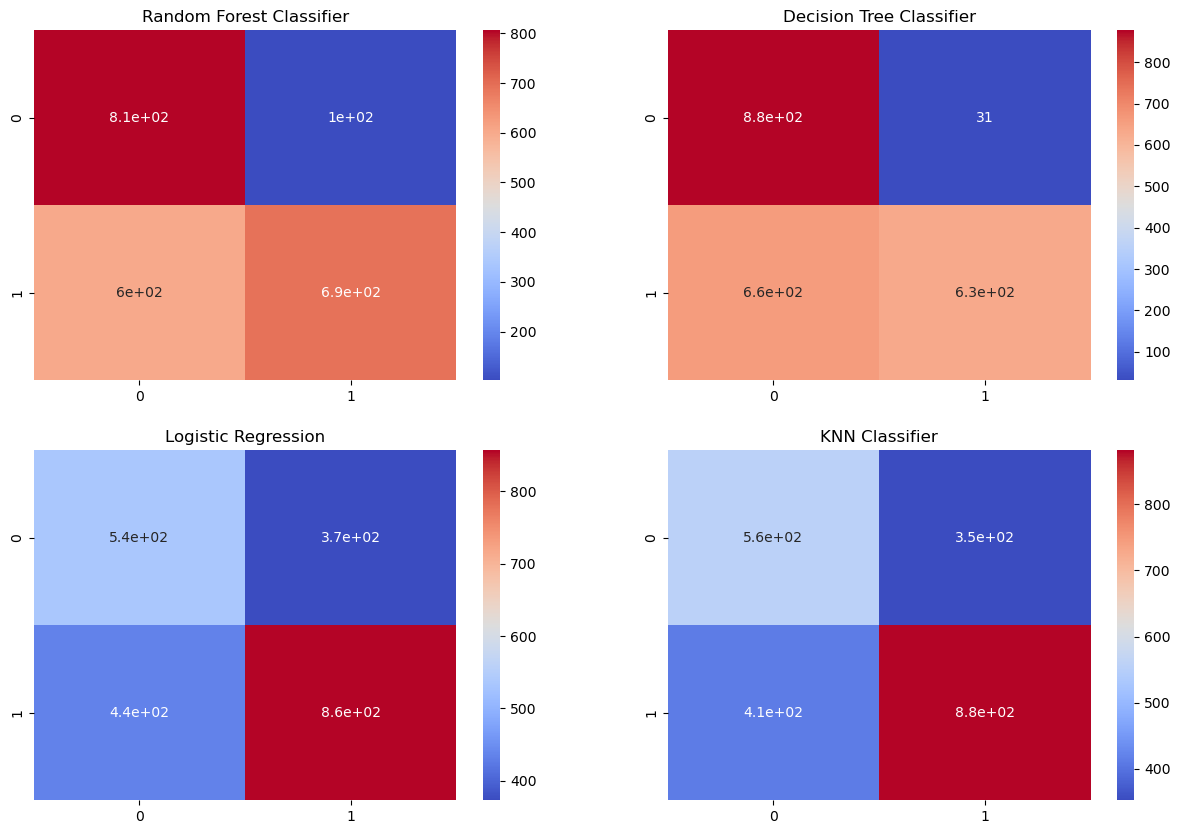

In [216]:
fig, ax = plt.subplots(2,2,figsize=(15,10))
sns.heatmap(confusion_matrix(y_test, rfc_pred), annot=True, cmap='coolwarm', ax=ax[0,0]).set_title('Random Forest Classifier')
sns.heatmap(confusion_matrix(y_test, dtc_pred), annot=True, cmap='coolwarm', ax=ax[0,1]).set_title('Decision Tree Classifier')
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, cmap='coolwarm', ax=ax[1,0]).set_title('Logistic Regression')
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, cmap='coolwarm', ax=ax[1,1]).set_title('KNN Classifier')

In [218]:
#classification report
print('Random Forest Classifier: \n', classification_report(y_test, rfc_pred))
print('Decision Tree Classifier: \n', classification_report(y_test, dtc_pred))
print('Logistic Regression: \n', classification_report(y_test, lr_pred))
print('KNN Classifier: \n', classification_report(y_test, knn_pred))

Random Forest Classifier: 
               precision    recall  f1-score   support

           0       0.57      0.89      0.70       908
           1       0.87      0.54      0.66      1292

    accuracy                           0.68      2200
   macro avg       0.72      0.71      0.68      2200
weighted avg       0.75      0.68      0.68      2200

Decision Tree Classifier: 
               precision    recall  f1-score   support

           0       0.57      0.97      0.72       908
           1       0.95      0.49      0.65      1292

    accuracy                           0.69      2200
   macro avg       0.76      0.73      0.68      2200
weighted avg       0.80      0.69      0.68      2200

Logistic Regression: 
               precision    recall  f1-score   support

           0       0.55      0.59      0.57       908
           1       0.70      0.66      0.68      1292

    accuracy                           0.63      2200
   macro avg       0.62      0.63      0.62      

# <p style="background-color:AntiqueWhite; font-family:calibri; color:DimGrey; font-size:100%; text-align:center;border-radius:15px 50px;">Model Comparison</p>

C:\Users\saiso\AppData\Local\Temp\ipykernel_38240\1340104463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracy, palette='magma').set_title('Model Comparison')


Text(0, 0.5, 'Accuracy')

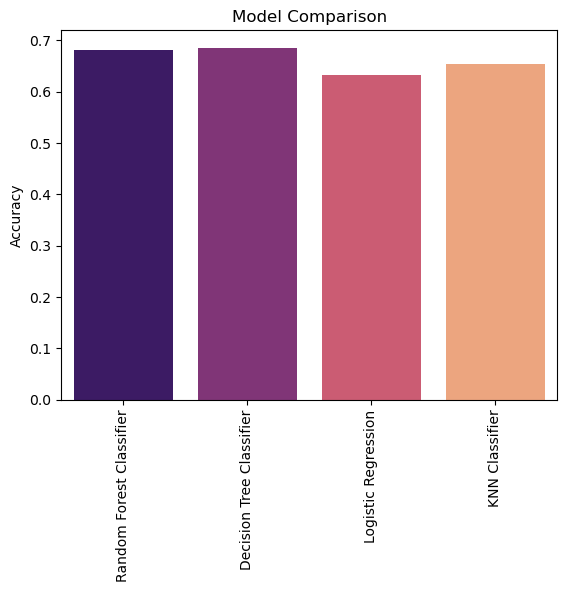

In [221]:
models = ['Random Forest Classifier', 'Decision Tree Classifier', 'Logistic Regression', 'KNN Classifier']
accuracy = [accuracy_score(y_test, rfc_pred), accuracy_score(y_test, dtc_pred), accuracy_score(y_test, lr_pred), accuracy_score(y_test, knn_pred)]
sns.barplot(x=models, y=accuracy, palette='magma').set_title('Model Comparison')
plt.xticks(rotation=90)
plt.ylabel('Accuracy')

# Conclusion

* The project's objective was to forecast on-time delivery for an e-commerce company's products and to explore factors influencing delivery times and customer behavior. The exploratory analysis highlighted that product weight and cost are crucial to delivery success, with products in the 2500-3500 gram range and priced under $250 being more likely to arrive on time. A significant volume of products was dispatched from warehouse F using shipping, suggesting its proximity to a seaport.
 
* Customer behavior also sheds light on delivery outcomes. An increase in customer care calls often correlates with delivery delays. In contrast, customers with a history of multiple purchases tend to experience more punctual deliveries, which might explain their repeat business. As for discounts, products with minimal discounts (0-10%) saw more late deliveries, while those with discounts exceeding 10% were more often delivered on time.
 
* Regarding machine learning models, the random forest classifier outperformed others with a 72% accuracy rate. Close behind were the random forest classifier and logistic regression, with 68% and 67% accuracy, respectively. The K Nearest Neighbors model trailed with the least accuracy at 65%.


<a id="conclusion"></a>
# <p style="background-color:DarkOrange; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;"> THANKYOU